In [1]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt
import re

ERROR! Session/line number was not unique in database. History logging moved to new session 6233


In [2]:
mes = 'Noviembre'
año = '2025'

In [3]:
#Importar archivos de acciones reg Zonal

carpeta_origen = 'Z:/01 base_datos/09 acciones_regulacion'

dataframes = [] # Lista para almacenar cada archivo

fecha_inicio = '01/11/2025'  
fecha_fin = '30/11/2025'  

for archivo in os.listdir(carpeta_origen):
    if archivo.endswith('.csv'):  # Filtra solo los archivos con extensión .csv
        ruta_archivo = os.path.join(carpeta_origen, archivo)
        df = pd.read_csv(ruta_archivo, encoding='latin')
        
        # Obtener la fecha del nombre del archivo
        fecha_archivo = pd.to_datetime(archivo.split('_')[0], format='%Y%m%d', errors='coerce')

        # Filtrar por fechas
        if fecha_archivo >= pd.to_datetime(fecha_inicio, format='%d/%m/%Y') and fecha_archivo <= pd.to_datetime(fecha_fin, format='%d/%m/%Y'):
            dataframes.append(df)  # Agregar el DataFrame a la lista

# Combinar todos los DataFrames en uno solo
if dataframes:
    resultado = pd.concat(dataframes)

    # Imprimir el resultado
    resultado
else:
    print("No se encontraron archivos que cumplan con el filtro de fechas.")
    

In [4]:
# Lista de valores de Accion que deseas incluir en el filtro
valores_interes = [2]

# Filtrar el DataFrame por los valores de Accion de interés
resultado = resultado[resultado['Motivo'].isin(valores_interes)]

resultado

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
453,1/11/2025,8:41:34,1413,13,Z50-4394,504394,5,Eliminar Coche,PAE,Edith Patarroyo,GMZ05,"<EliminarCoche Servicio=""CEIJH0013"" Motivo=""2""...",2,Bus varado en la vía
472,1/11/2025,8:59:03,1300,9,Z50-7052,507052,5,Eliminar Coche,BEJA,Jenny Alexandra Bernal,GMZ03,"<EliminarCoche Servicio=""CNLY40009"" Motivo=""2""...",2,Bus varado en la vía
544,1/11/2025,10:05:10,1407,16,Z50-2015,502015,5,Eliminar Coche,rmican,Raúl Fabián Romero Micán,GMZ04,"<EliminarCoche Servicio=""CEIJB0016"" Motivo=""2""...",2,Bus varado en la vía
636,1/11/2025,11:32:45,1215,22,Z52-4006,524006,5,Eliminar Coche,BEJA,Jenny Alexandra Bernal,GMZ03,"<EliminarCoche Servicio=""CEIJZH007"" Motivo=""2""...",2,Bus varado en la vía
678,1/11/2025,12:05:13,1215,5,Z50-4413,504413,5,Eliminar Coche,BEJA,Jenny Alexandra Bernal,GMZ03,"<EliminarCoche Servicio=""CEIJZ0006"" Motivo=""2""...",2,Bus varado en la vía
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1338,20/11/2025,17:56:42,1208,19,Z50-2122,502122,5,Eliminar Coche,LMVG,Laura Marcela Vargas Gutierrez,GMZ05,"<EliminarCoche Servicio=""CEIKA0019"" Motivo=""2""...",2,Bus varado en la vía
1544,20/11/2025,19:36:30,1099,3,Z50-4011,504011,5,Eliminar Coche,jespinosa1,John Jairo Espinosa Santa,GMZ03,"<EliminarCoche Servicio=""CEIMP0003"" Motivo=""2""...",2,Bus varado en la vía
1562,20/11/2025,19:43:38,1099,21,Z50-2037,502037,5,Eliminar Coche,jespinosa1,John Jairo Espinosa Santa,GMZ03,"<EliminarCoche Servicio=""CEIMPG011"" Motivo=""2""...",2,Bus varado en la vía
1602,20/11/2025,19:59:53,1557,36,Z50-4486,504486,5,Eliminar Coche,YIHA,Yerly Irene Hernandez Ariza,GMZ06,"<EliminarCoche Servicio=""CEILCG001"" Motivo=""2""...",2,Bus varado en la vía


In [5]:
resultado = resultado[resultado['Puesto'].str.startswith('GM', na=False)]

resultado

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
453,1/11/2025,8:41:34,1413,13,Z50-4394,504394,5,Eliminar Coche,PAE,Edith Patarroyo,GMZ05,"<EliminarCoche Servicio=""CEIJH0013"" Motivo=""2""...",2,Bus varado en la vía
472,1/11/2025,8:59:03,1300,9,Z50-7052,507052,5,Eliminar Coche,BEJA,Jenny Alexandra Bernal,GMZ03,"<EliminarCoche Servicio=""CNLY40009"" Motivo=""2""...",2,Bus varado en la vía
544,1/11/2025,10:05:10,1407,16,Z50-2015,502015,5,Eliminar Coche,rmican,Raúl Fabián Romero Micán,GMZ04,"<EliminarCoche Servicio=""CEIJB0016"" Motivo=""2""...",2,Bus varado en la vía
636,1/11/2025,11:32:45,1215,22,Z52-4006,524006,5,Eliminar Coche,BEJA,Jenny Alexandra Bernal,GMZ03,"<EliminarCoche Servicio=""CEIJZH007"" Motivo=""2""...",2,Bus varado en la vía
678,1/11/2025,12:05:13,1215,5,Z50-4413,504413,5,Eliminar Coche,BEJA,Jenny Alexandra Bernal,GMZ03,"<EliminarCoche Servicio=""CEIJZ0006"" Motivo=""2""...",2,Bus varado en la vía
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1338,20/11/2025,17:56:42,1208,19,Z50-2122,502122,5,Eliminar Coche,LMVG,Laura Marcela Vargas Gutierrez,GMZ05,"<EliminarCoche Servicio=""CEIKA0019"" Motivo=""2""...",2,Bus varado en la vía
1544,20/11/2025,19:36:30,1099,3,Z50-4011,504011,5,Eliminar Coche,jespinosa1,John Jairo Espinosa Santa,GMZ03,"<EliminarCoche Servicio=""CEIMP0003"" Motivo=""2""...",2,Bus varado en la vía
1562,20/11/2025,19:43:38,1099,21,Z50-2037,502037,5,Eliminar Coche,jespinosa1,John Jairo Espinosa Santa,GMZ03,"<EliminarCoche Servicio=""CEIMPG011"" Motivo=""2""...",2,Bus varado en la vía
1602,20/11/2025,19:59:53,1557,36,Z50-4486,504486,5,Eliminar Coche,YIHA,Yerly Irene Hernandez Ariza,GMZ06,"<EliminarCoche Servicio=""CEILCG001"" Motivo=""2""...",2,Bus varado en la vía


In [6]:
# Filtrar el DataFrame resultado
resultado = resultado.loc[resultado['Accion'] != 5]

resultado

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
2038,6/11/2025,20:20:04,1413,40,Z50-4000,504000,3,Eliminación Entre Paradas,CRSC,Sonia Constanza Correa Rodriguez,GMZ01,"<CocheNoDisponible Servicio=""CEIKCG027"" IdViaj...",2,Bus varado en la vía
697,19/11/2025,9:11:46,1030,30,Z50-4383,504383,27,Vacío/Limitación,PAE,Edith Patarroyo,GMZ09,"<VacioLimitacion Accion=""Vacio"" Desde=""PA55900...",2,Bus varado en la vía


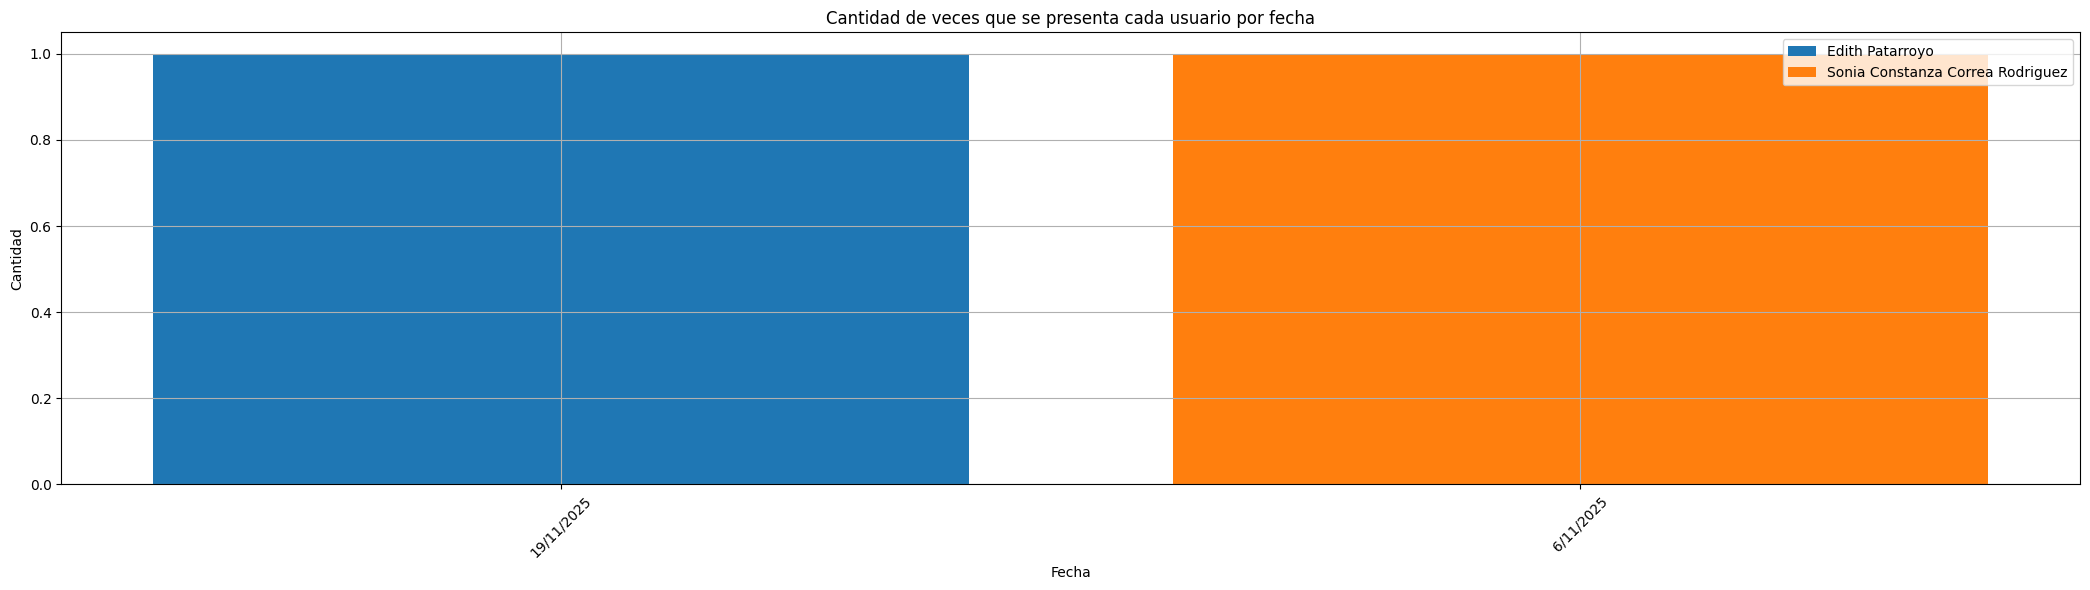

In [7]:
# Agrupar los datos por NombreUsuario y Fecha y contar las ocurrencias
conteo_por_fecha = resultado.groupby(['NombreUsuario', 'Fecha']).size().reset_index(name='Conteo')

# Crear la gráfica de barras
plt.figure(figsize=(21, 6))
for nombre_usuario in conteo_por_fecha['NombreUsuario'].unique():
    datos_usuario = conteo_por_fecha[conteo_por_fecha['NombreUsuario'] == nombre_usuario]
    plt.bar(datos_usuario['Fecha'], datos_usuario['Conteo'], label=nombre_usuario)

# Personalizar la gráfica
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.title('Cantidad de veces que se presenta cada usuario por fecha')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

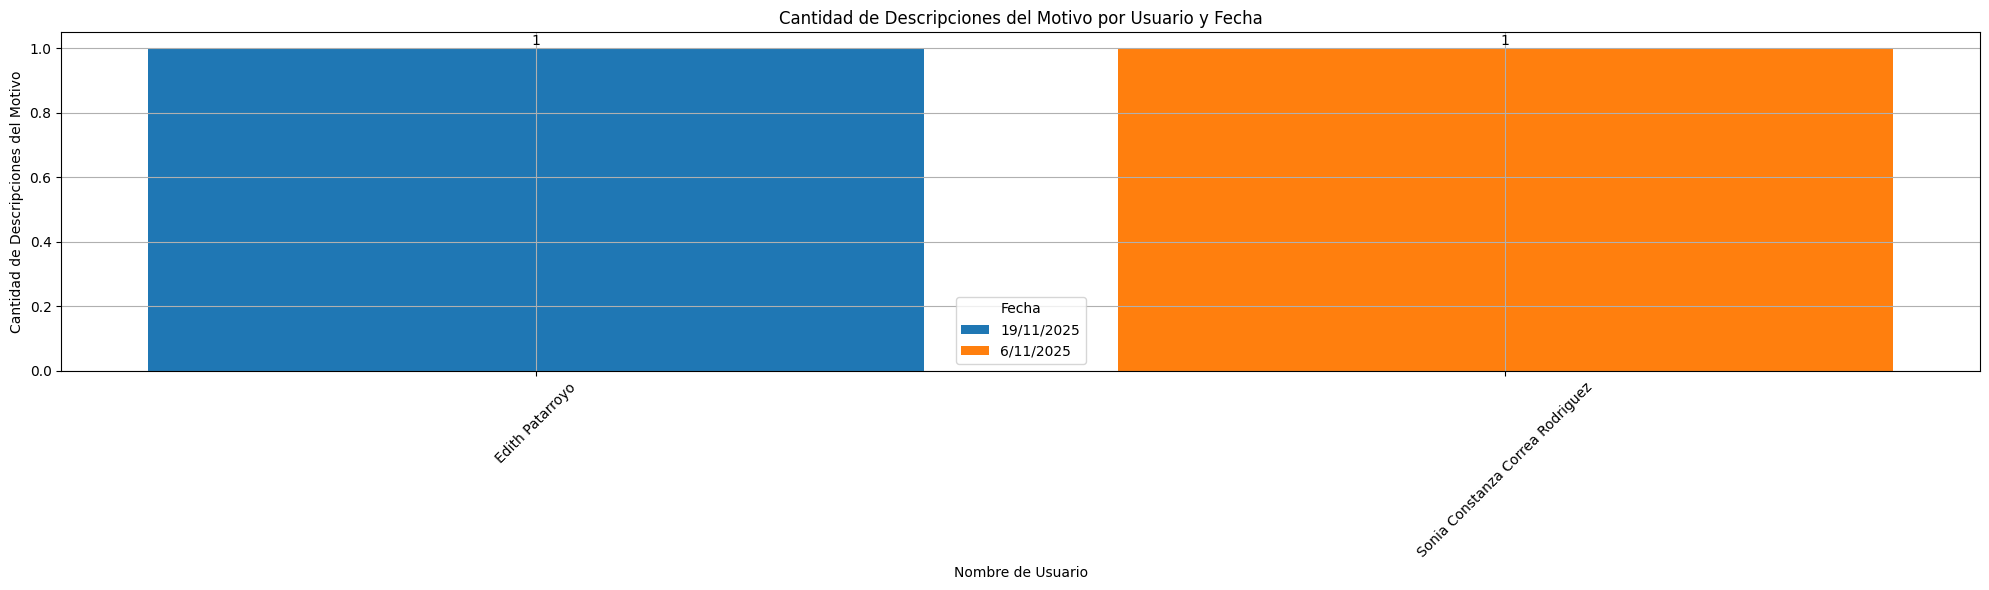

In [8]:
# Agrupar los datos por NombreUsuario y Fecha y contar las descripciones del motivo
conteo_por_usuario_fecha = resultado.groupby(['NombreUsuario', 'Fecha'])['DescripcionMotivo'].count().reset_index(name='Cantidad')

# Crear la gráfica de barras
plt.figure(figsize=(20, 6))
for fecha in conteo_por_usuario_fecha['Fecha'].unique():
    datos_fecha = conteo_por_usuario_fecha[conteo_por_usuario_fecha['Fecha'] == fecha]
    plt.bar(datos_fecha['NombreUsuario'], datos_fecha['Cantidad'], label=fecha)

# Agregar etiquetas a las barras
for index, row in conteo_por_usuario_fecha.iterrows():
    plt.text(row['NombreUsuario'], row['Cantidad'], str(row['Cantidad']), ha='center', va='bottom')

# Personalizar la gráfica
plt.xlabel('Nombre de Usuario')
plt.ylabel('Cantidad de Descripciones del Motivo')
plt.title('Cantidad de Descripciones del Motivo por Usuario y Fecha')
plt.xticks(rotation=45)
plt.legend(title='Fecha')
plt.grid(True)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

In [9]:
#Exportar data
resultado.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2025/Motivos_infracciones/{mes}_{año}.csv')